# Import

In [1]:
import os
import glob
import cv2
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# Picture Acquisition

In [2]:

def load_image_and_remove_padding(
        image_path,
        min_valid_intensity=2,
        return_mask=False):
    """
    Load grayscale EL image and remove padding/bezel pixels.

    Parameters
    ----------
    image_path : str
        Path ke file .tiff
    min_valid_intensity : int
        Threshold untuk buang padding (default 2)
    return_mask : bool
        Kalau True, return juga mask 2D untuk visualisasi

    Returns
    -------
    phi_values : 1D numpy array
        Pixel intensity valid (tanpa padding)
    mask (optional) : 2D boolean array
    """

    # Load image grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Gagal load image: {image_path}")

    img = img.astype(np.float64)

    # Mask padding
    mask = img >= min_valid_intensity

    intensity_map = img[mask]

    if intensity_map.size == 0:
        raise ValueError("Tidak ada pixel valid setelah padding removal.")

    if return_mask:
        return intensity_map, mask
    else:
        return intensity_map


def trim_outliers(values, lower_percentile=0.1, upper_percentile=99.9):
    """
    Remove extreme outliers from a 1D array using percentile thresholds.

    Parameters
    ----------
    values : array-like
        Input data (misalnya intensity pixel).
    lower_percentile : float
        Persentil bawah yang dipertahankan.
    upper_percentile : float
        Persentil atas yang dipertahankan.

    Returns
    -------
    trimmed_values : numpy array
        Array tanpa outlier.
    """

    v = np.asarray(values, dtype=np.float64)

    # buang NaN
    v = v[np.isfinite(v)]

    if v.size == 0:
        return v

    lo = np.percentile(v, lower_percentile)
    hi = np.percentile(v, upper_percentile)

    trimmed = v[(v >= lo) & (v <= hi)]

    return trimmed

In [3]:
def load_image_and_remove_padding(
        image_path,
        min_valid_intensity=2,
        return_mask=False,
        floor=1e-6,
        ceil=0.999):
    """
    Load grayscale EL image, remove padding, normalize intensity to [0,1],
    apply floor and upper clipping.

    Parameters
    ----------
    image_path : str
        Path ke file .tiff
    min_valid_intensity : int
        Threshold untuk buang padding
    return_mask : bool
        Jika True return mask 2D
    floor : float
        Nilai minimum setelah normalisasi
    ceil : float
        Nilai maksimum setelah normalisasi

    Returns
    -------
    phi_values : 1D numpy array
        Pixel intensity valid (range floor–ceil)
    mask (optional) : 2D boolean array
    """

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Gagal load image: {image_path}")

    img = img.astype(np.float64)

    # remove padding
    mask = img >= min_valid_intensity
    intensity_map = img[mask]

    if intensity_map.size == 0:
        raise ValueError("Tidak ada pixel valid setelah padding removal.")

    # normalize
    min_val = intensity_map.min()
    max_val = intensity_map.max()

    intensity_map = (intensity_map - min_val) / (max_val - min_val)

    # apply floor + ceiling
    intensity_map = np.clip(intensity_map, floor, ceil)

    if return_mask:
        return intensity_map, mask
    else:
        return intensity_map

# I0 by Rajput, 2018

In [4]:

def compute_f(intensity_map, I, Uth=0.0259, VT=0.0, N=1, pixel_area=1.0):
    """
    intensity_map di sini diasumsikan sudah berupa 1D cleaned values
    (padding removed, normalized, clipped).
    """
    phi_valid = np.asarray(intensity_map, dtype=np.float64)

    phi_valid = phi_valid[np.isfinite(phi_valid)]
    phi_valid = phi_valid[phi_valid > 0]

    if phi_valid.size == 0:
        raise ValueError("Tidak ada pixel valid untuk menghitung f.")

    integral_inv_phi = np.sum((1.0 / phi_valid) * pixel_area)

    log_term = np.log(I / integral_inv_phi)
    sum_term = N * (Uth / 2.0) * log_term
    exponent = (sum_term - VT) / (30.0 * Uth)

    return float(np.exp(exponent))


def compute_Vi_from_phi_values(intensity_map,
                               I,
                               f,
                               Uth=0.0259,
                               pixel_area=1.0):
    """
    Compute terminal voltage:
        Vi = (Uth/2) * ln( I / ( f * ∫(1/phi) d^2r ) )

    Parameters
    ----------
    phi_values : 1D numpy array
        Cleaned intensity values (padding removed already).
    I : float
        Injected current (Ampere).
    f : float
        Calibration factor.
    Uth : float
        Thermal voltage (kT/q or effective).
    pixel_area : float
        Area per pixel (set 1.0 if you only need relative scale).

    Returns
    -------
    Vi : float
        Terminal voltage (Volt).
    """
    phi = np.asarray(intensity_map, dtype=np.float64)

    if phi.size == 0:
        raise ValueError("phi_values kosong.")
    if np.any(phi <= 0):
        raise ValueError("phi_values mengandung nilai <= 0 (tidak boleh untuk 1/phi dan log).")
    if f <= 0 or I <= 0:
        raise ValueError("I dan f harus > 0.")

    integral_inv_phi = np.sum((1.0 / phi) * float(pixel_area))
    if integral_inv_phi <= 0:
        raise ValueError("Integral ∑(1/phi)*dA tidak valid.")

    arg = I / (f * integral_inv_phi)
    if arg <= 0:
        raise ValueError("Argumen log tidak valid (<=0).")

    Vi = (Uth / 2.0) * np.log(arg)
    return float(Vi)


def compute_c_map(phi_image, Vi, Uth=0.0259, min_valid_intensity=2):
    """
    Compute c(r) map in 2D.

    c(r) = Phi(r) * exp( -Vi / Uth )
    (Low bias assumption: U(r) ≈ Vi)

    Returns:
        c_map (2D numpy array)
        mask   (valid pixel mask)
    """
    phi = phi_image.astype(np.float64)

    mask = phi >= min_valid_intensity

    c_map = np.full_like(phi, np.nan, dtype=np.float64)

    scale = np.exp(-float(Vi) / float(Uth))

    c_map[mask] = phi[mask] * scale

    return c_map, mask


def compute_J0_map(c_map, f):
    """
    Compute J0(r) map in 2D:

    J0(r) = f / c(r)

    Returns:
        J0_map (2D numpy array)
    """
    if f <= 0:
        raise ValueError("f harus > 0.")

    J0_map = np.full_like(c_map, np.nan, dtype=np.float64)

    valid = np.isfinite(c_map) & (c_map > 0)

    J0_map[valid] = float(f) / c_map[valid]

    return J0_map

# Rs by Rajput, 2018

In [5]:
import cv2
import numpy as np

def load_gray_cv2(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal load image: {path}")
    return img.astype(np.float64)

def make_valid_mask(phi: np.ndarray, min_valid_intensity: int = 2) -> np.ndarray:
    # buang padding/bezel 0-1
    return (phi >= float(min_valid_intensity)) & np.isfinite(phi)

def compute_U_map(phi: np.ndarray, c_map: np.ndarray, Uth: float, mask: np.ndarray) -> np.ndarray:
    """
    U(r) = Uth * ln( Phi(r) / c(r) )
    """
    if phi.shape != c_map.shape:
        raise ValueError("phi dan c_map harus punya shape yang sama.")
    U = np.full_like(phi, np.nan, dtype=np.float64)

    safe = mask & np.isfinite(c_map) & (c_map > 0) & (phi > 0)
    U[safe] = Uth * np.log(phi[safe] / c_map[safe])
    return U

def estimate_Vi_from_brightest(phi: np.ndarray, U_map: np.ndarray, mask: np.ndarray,
                               exclude_top_percent: float = 0.1,
                               band_width_percent: float = 0.4) -> float:
    """
    Vi diambil dari area paling terang (brightest spot), exclude top 0.1% intensitas
    untuk menghindari outlier/saturasi. Vi = median(U) di band intensitas near-brightest.
    """
    safe = mask & np.isfinite(U_map) & np.isfinite(phi)
    vals = phi[safe]
    if vals.size < 50:
        raise ValueError("Terlalu sedikit pixel valid untuk estimasi Vi.")

    p_hi = 100.0 - exclude_top_percent       # contoh 99.9
    p_lo = max(p_hi - band_width_percent, 0) # contoh 99.5

    thr_hi = np.percentile(vals, p_hi)
    thr_lo = np.percentile(vals, p_lo)

    band = safe & (phi >= thr_lo) & (phi <= thr_hi)
    U_band = U_map[band]

    if U_band.size == 0:
        # fallback: ambil U maksimum di bawah thr_hi
        cand = safe & (phi <= thr_hi)
        return float(np.nanmax(U_map[cand]))

    return float(np.nanmedian(U_band))

def compute_J_map(J0_map: np.ndarray, U_map: np.ndarray, Uth: float, mask: np.ndarray) -> np.ndarray:
    """
    J(r) = J0(r) * exp(U/Uth)
    """
    if J0_map.shape != U_map.shape:
        raise ValueError("J0_map dan U_map harus punya shape yang sama.")
    J = np.full_like(U_map, np.nan, dtype=np.float64)
    safe = mask & np.isfinite(J0_map) & (J0_map > 0) & np.isfinite(U_map)
    J[safe] = J0_map[safe] * np.exp(U_map[safe] / Uth)
    return J

def compute_Rs_map(Vi: float, U_map: np.ndarray, J_map: np.ndarray, mask: np.ndarray,
                   min_abs_J: float = 1e-30) -> np.ndarray:
    """
    Rs(r) = (Vi - U(r)) / J(r)
    min_abs_J mencegah division blow-up di area J sangat kecil.
    """
    Rs = np.full_like(U_map, np.nan, dtype=np.float64)
    safe = mask & np.isfinite(U_map) & np.isfinite(J_map) & (np.abs(J_map) > min_abs_J)
    Rs[safe] = (float(Vi) - U_map[safe]) / J_map[safe]
    return Rs/Rs[safe].size # normalisasi Rs dengan jumlah pixel valid untuk mendapatkan nilai rata-rata per pixel

def estimate_U_J_Rs_maps_from_highbias(
    phi_high_path: str,
    c_map: np.ndarray,
    J0_map: np.ndarray,
    Uth: float = 0.0259,
    min_valid_intensity: int = 2,
    exclude_top_percent: float = 0.1,
    band_width_percent: float = 0.4
):
    """
    High-bias pipeline:
    1) Load phi_high
    2) U_map = Uth ln(phi/c)
    3) Vi = median U pada brightest region (exclude top 0.1% phi)
    4) J_map = J0 exp(U/Uth)
    5) Rs_map = (Vi - U) / J
    """
    phi = load_gray_cv2(phi_high_path)
    mask = make_valid_mask(phi, min_valid_intensity=min_valid_intensity)

    U_map = compute_U_map(phi, c_map=c_map, Uth=Uth, mask=mask)
    Vi = estimate_Vi_from_brightest(phi, U_map=U_map, mask=mask,
                                    exclude_top_percent=exclude_top_percent,
                                    band_width_percent=band_width_percent)
    J_map = compute_J_map(J0_map=J0_map, U_map=U_map, Uth=Uth, mask=mask)
    Rs_map = compute_Rs_map(Vi=Vi, U_map=U_map, J_map=J_map, mask=mask)

    return {
        "phi_high": phi,
        "mask": mask,
        "Vi": Vi,
        "U_map": U_map,
        "J_map": J_map,
        "Rs_map": Rs_map
    }

# Rp by Timo Kropp

In [6]:
import os
import glob
import cv2
import numpy as np
from scipy.special import lambertw


def load_gray_tiff_cv2(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal load image: {path}")
    return img.astype(np.float32)


def mean_intensity_excluding_padding(img: np.ndarray, min_valid: int = 2) -> float:
    """
    Hitung mean intensity dengan buang pixel 0-1 (padding/bezel).
    """
    m = img >= float(min_valid)
    if np.sum(m) == 0:
        return float("nan")
    return float(np.mean(img[m]))


def compute_CPRA(phi_ref: float, J0: float, nid: float, Vth: float, rref_p: float) -> float:
    """
    Hitung CPRA berdasarkan reference cell.
    """
    a = (J0 * rref_p) / (nid * Vth)
    W = lambertw(a * np.exp(a), k=0)
    W = np.real(W)

    if W <= 0:
        raise ValueError("LambertW menghasilkan nilai non-positif. Cek parameter J0, nid, rref_p.")

    CPRA = (J0 * rref_p * phi_ref) / (nid * Vth * W)
    return float(CPRA)


def rp_from_mean_intensity(phi_i: float, CPRA: float, Jc: float, J0: float, nid: float, Vth: float) -> float:
    """
    Hitung Rp dari mean intensity.
    """
    if not np.isfinite(phi_i) or phi_i <= 0:
        return float("nan")

    x = phi_i / CPRA
    if x <= 0:
        return float("nan")

    num = nid * Vth * np.log(x)
    den = Jc - J0 * x

    if den <= 0:
        return float("nan")

    rp = num / den
    if rp <= 0:
        return float("nan")

    return float(rp)



# Uniting Program

## Rs Estimation Program Check

### Function-Function

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt


def clip_for_display(img, mask, p_low=2, p_high=98):
    vals = img[mask & np.isfinite(img)]
    if vals.size == 0:
        return img
    lo, hi = np.percentile(vals, [p_low, p_high])
    return np.clip(img, lo, hi)


def summarize_map(name, arr, mask):
    vals = arr[mask & np.isfinite(arr)]
    if vals.size == 0:
        print(f"{name:12s}: tidak ada nilai valid")
        return {
            "mean": np.nan,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n": 0
        }

    summary = {
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "n": int(vals.size)
    }

    print(
        f"{name:12s}: "
        f"mean = {summary['mean']:.6f}, "
        f"median = {summary['median']:.6f}, "
        f"min = {summary['min']:.6f}, "
        f"max = {summary['max']:.6f}, "
        f"n = {summary['n']}"
    )
    return summary


def run_single_cell_analysis(
    low_cell_path,
    high_cell_path,
    I_low,
    Uth=0.0259,
    VT=0.0,
    N=1,
    min_valid_intensity=2
):
    # ----------------------------
    # LOW-BIAS
    # ----------------------------
    phi_low_values = load_image_and_remove_padding(
        low_cell_path,
        min_valid_intensity=min_valid_intensity
    )
    phi_low_values = trim_outliers(
        phi_low_values,
        lower_percentile=0.1,
        upper_percentile=99.9
    )

    f = compute_f(phi_low_values, I=I_low, Uth=Uth, VT=VT, N=N)
    Vi_low = compute_Vi_from_phi_values(phi_low_values, I=I_low, f=f, Uth=Uth)

    phi_low_img = load_gray_cv2(low_cell_path)
    c_map, mask_low = compute_c_map(
        phi_low_img,
        Vi=Vi_low,
        Uth=Uth,
        min_valid_intensity=min_valid_intensity
    )
    J0_map = compute_J0_map(c_map, f=f)

    # ----------------------------
    # HIGH-BIAS
    # ----------------------------
    phi_high_img = load_gray_cv2(high_cell_path)
    mask_high = make_valid_mask(phi_high_img, min_valid_intensity=min_valid_intensity)
    mask = mask_low & mask_high

    U_map = compute_U_map(
        phi_high_img,
        c_map=c_map,
        Uth=Uth,
        mask=mask
    )

    Vi_high = estimate_Vi_from_brightest(
        phi_high_img,
        U_map=U_map,
        mask=mask,
        exclude_top_percent=0.1,
        band_width_percent=0.4
    )

    J_map = compute_J_map(
        J0_map=J0_map,
        U_map=U_map,
        Uth=Uth,
        mask=mask
    )

    Rs_map = compute_Rs_map(
        Vi=Vi_high,
        U_map=U_map,
        J_map=J_map,
        mask=mask
    )

    # ----------------------------
    # SUMMARY
    # ----------------------------
    print("=" * 90)
    print("SINGLE CELL ANALYSIS")
    print("-" * 90)
    print("Low cell file  :", os.path.basename(low_cell_path))
    print("High cell file :", os.path.basename(high_cell_path))
    print(f"I_low          : {I_low}")
    print(f"Uth            : {Uth}")
    print(f"VT             : {VT}")
    print(f"N              : {N}")
    print(f"f              : {f}")
    print(f"Vi_low         : {Vi_low}")
    print(f"Vi_high        : {Vi_high}")
    print("=" * 90)

    summaries = {}

    # intensity summaries
    low_vals_valid = phi_low_img[mask & np.isfinite(phi_low_img)]
    high_vals_valid = phi_high_img[mask & np.isfinite(phi_high_img)]

    print("\nINTENSITY SUMMARY")
    print("-" * 90)

    if low_vals_valid.size > 0:
        print(
            f"{'Low intensity':12s}: "
            f"mean = {np.mean(low_vals_valid):.6f}, "
            f"median = {np.median(low_vals_valid):.6f}, "
            f"min = {np.min(low_vals_valid):.6f}, "
            f"max = {np.max(low_vals_valid):.6f}, "
            f"n = {low_vals_valid.size}"
        )
        summaries["low_intensity_mean"] = float(np.mean(low_vals_valid))
    else:
        print("Low intensity: tidak ada nilai valid")
        summaries["low_intensity_mean"] = np.nan

    if high_vals_valid.size > 0:
        print(
            f"{'High intensity':12s}: "
            f"mean = {np.mean(high_vals_valid):.6f}, "
            f"median = {np.median(high_vals_valid):.6f}, "
            f"min = {np.min(high_vals_valid):.6f}, "
            f"max = {np.max(high_vals_valid):.6f}, "
            f"n = {high_vals_valid.size}"
        )
        summaries["high_intensity_mean"] = float(np.mean(high_vals_valid))
    else:
        print("High intensity: tidak ada nilai valid")
        summaries["high_intensity_mean"] = np.nan

    print("\nMAP SUMMARY")
    print("-" * 90)
    summaries["c_map"] = summarize_map("c_map", c_map, mask)
    summaries["J0_map"] = summarize_map("J0_map", J0_map, mask)
    summaries["U_map"] = summarize_map("U_map", U_map, mask)
    summaries["J_map"] = summarize_map("J_map", J_map, mask)
    summaries["Rs_map"] = summarize_map("Rs_map", Rs_map, mask)

    # ----------------------------
    # DISPLAY IMAGES
    # ----------------------------
    phi_low_disp = clip_for_display(phi_low_img, mask, 2, 98)
    phi_high_disp = clip_for_display(phi_high_img, mask, 2, 98)
    c_disp = clip_for_display(c_map, mask, 2, 98)
    J0_disp = clip_for_display(J0_map, mask, 2, 98)
    U_disp = clip_for_display(U_map, mask, 2, 98)
    J_disp = clip_for_display(J_map, mask, 2, 98)
    Rs_disp = clip_for_display(Rs_map, mask, 2, 98)

    mask_disp = np.where(mask, 1.0, 0.0)

    plt.figure(figsize=(16, 12))

    plt.subplot(2, 4, 1)
    plt.imshow(phi_low_disp, cmap="gray")
    plt.title("Low intensity")
    plt.colorbar()

    plt.subplot(2, 4, 2)
    plt.imshow(phi_high_disp, cmap="gray")
    plt.title("High intensity")
    plt.colorbar()

    plt.subplot(2, 4, 3)
    plt.imshow(mask_disp, cmap="gray")
    plt.title("Valid mask")
    plt.colorbar()

    plt.subplot(2, 4, 4)
    plt.imshow(c_disp, cmap="viridis")
    plt.title("c_map")
    plt.colorbar()

    plt.subplot(2, 4, 5)
    plt.imshow(J0_disp, cmap="plasma")
    plt.title("J0_map")
    plt.colorbar()

    plt.subplot(2, 4, 6)
    plt.imshow(U_disp, cmap="magma")
    plt.title("U_map")
    plt.colorbar()

    plt.subplot(2, 4, 7)
    plt.imshow(J_disp, cmap="inferno")
    plt.title("J_map")
    plt.colorbar()

    plt.subplot(2, 4, 8)
    plt.imshow(Rs_disp, cmap="cividis")
    plt.title("Rs_map")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    return {
        "f": f,
        "Vi_low": Vi_low,
        "Vi_high": Vi_high,
        "mask": mask,
        "phi_low_img": phi_low_img,
        "phi_high_img": phi_high_img,
        "c_map": c_map,
        "J0_map": J0_map,
        "U_map": U_map,
        "J_map": J_map,
        "Rs_map": Rs_map,
        "summaries": summaries
    }




In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt


def clip_for_display(img, mask, p_low=2, p_high=98):
    vals = img[mask & np.isfinite(img)]
    if vals.size == 0:
        return img
    lo, hi = np.percentile(vals, [p_low, p_high])
    return np.clip(img, lo, hi)


def summarize_map(name, arr, mask):
    vals = arr[mask & np.isfinite(arr)]
    if vals.size == 0:
        print(f"{name:12s}: tidak ada nilai valid")
        return {
            "mean": np.nan,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n": 0
        }

    summary = {
        "mean": float(np.mean(vals)),
        "median": float(np.median(vals)),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "n": int(vals.size)
    }

    print(
        f"{name:12s}: "
        f"mean = {summary['mean']:.6f}, "
        f"median = {summary['median']:.6f}, "
        f"min = {summary['min']:.6f}, "
        f"max = {summary['max']:.6f}, "
        f"n = {summary['n']}"
    )
    return summary


def run_single_cell_analysis(
    low_cell_path,
    high_cell_path,
    I_low,
    Uth=0.0259,
    VT=0.0,
    N=1,
    min_valid_intensity=2
):
    # ----------------------------
    # LOW-BIAS
    # ----------------------------
    phi_low_values = load_image_and_remove_padding(
        low_cell_path,
        min_valid_intensity=min_valid_intensity
    )
    phi_low_values = trim_outliers(
        phi_low_values,
        lower_percentile=0.1,
        upper_percentile=99.9
    )

    f = compute_f(phi_low_values, I=I_low, Uth=Uth, VT=VT, N=N)
    Vi_low = compute_Vi_from_phi_values(phi_low_values, I=I_low, f=f, Uth=Uth)

    phi_low_img = load_gray_cv2(low_cell_path)
    c_map, mask_low = compute_c_map(
        phi_low_img,
        Vi=Vi_low,
        Uth=Uth,
        min_valid_intensity=min_valid_intensity
    )
    J0_map = compute_J0_map(c_map, f=f)

    # ----------------------------
    # HIGH-BIAS
    # ----------------------------
    phi_high_img = load_gray_cv2(high_cell_path)
    mask_high = make_valid_mask(phi_high_img, min_valid_intensity=min_valid_intensity)
    mask = mask_low & mask_high

    U_map = compute_U_map(
        phi_high_img,
        c_map=c_map,
        Uth=Uth,
        mask=mask
    )

    Vi_high = estimate_Vi_from_brightest(
        phi_high_img,
        U_map=U_map,
        mask=mask,
        exclude_top_percent=0.1,
        band_width_percent=0.4
    )

    J_map = compute_J_map(
        J0_map=J0_map,
        U_map=U_map,
        Uth=Uth,
        mask=mask
    )

    Rs_map = compute_Rs_map(
        Vi=Vi_high,
        U_map=U_map,
        J_map=J_map,
        mask=mask
    )

    # ----------------------------
    # SUMMARY
    # ----------------------------
    print("=" * 90)
    print("SINGLE CELL ANALYSIS")
    print("-" * 90)
    print("Low cell file  :", os.path.basename(low_cell_path))
    print("High cell file :", os.path.basename(high_cell_path))
    print(f"I_low          : {I_low}")
    print(f"Uth            : {Uth}")
    print(f"VT             : {VT}")
    print(f"N              : {N}")
    print(f"f              : {f}")
    print(f"Vi_low         : {Vi_low}")
    print(f"Vi_high        : {Vi_high}")
    print("=" * 90)

    summaries = {}

    # intensity summaries
    low_vals_valid = phi_low_img[mask & np.isfinite(phi_low_img)]
    high_vals_valid = phi_high_img[mask & np.isfinite(phi_high_img)]

    print("\nINTENSITY SUMMARY")
    print("-" * 90)

    if low_vals_valid.size > 0:
        print(
            f"{'Low intensity':12s}: "
            f"mean = {np.mean(low_vals_valid):.6f}, "
            f"median = {np.median(low_vals_valid):.6f}, "
            f"min = {np.min(low_vals_valid):.6f}, "
            f"max = {np.max(low_vals_valid):.6f}, "
            f"n = {low_vals_valid.size}"
        )
        summaries["low_intensity_mean"] = float(np.mean(low_vals_valid))
    else:
        print("Low intensity: tidak ada nilai valid")
        summaries["low_intensity_mean"] = np.nan

    if high_vals_valid.size > 0:
        print(
            f"{'High intensity':12s}: "
            f"mean = {np.mean(high_vals_valid):.6f}, "
            f"median = {np.median(high_vals_valid):.6f}, "
            f"min = {np.min(high_vals_valid):.6f}, "
            f"max = {np.max(high_vals_valid):.6f}, "
            f"n = {high_vals_valid.size}"
        )
        summaries["high_intensity_mean"] = float(np.mean(high_vals_valid))
    else:
        print("High intensity: tidak ada nilai valid")
        summaries["high_intensity_mean"] = np.nan

    print("\nMAP SUMMARY")
    print("-" * 90)
    summaries["c_map"] = summarize_map("c_map", c_map, mask)
    summaries["J0_map"] = summarize_map("J0_map", J0_map, mask)
    summaries["U_map"] = summarize_map("U_map", U_map, mask)
    summaries["J_map"] = summarize_map("J_map", J_map, mask)
    summaries["Rs_map"] = summarize_map("Rs_map", Rs_map, mask)

        # ----------------------------
    # DISPLAY IMAGES
    # ----------------------------
    phi_low_disp = clip_for_display(phi_low_img, mask, 2, 98)
    phi_high_disp = clip_for_display(phi_high_img, mask, 2, 98)
    c_disp = clip_for_display(c_map, mask, 2, 98)
    J0_disp = clip_for_display(J0_map, mask, 2, 98)
    U_disp = clip_for_display(U_map, mask, 2, 98)
    J_disp = clip_for_display(J_map, mask, 2, 98)
    Rs_disp = clip_for_display(Rs_map, mask, 2, 98)

    mask_disp = np.where(mask, 1.0, 0.0)

    # Font settings
    FONT_SIZE = 25
    TITLE_SIZE = 25
    TICK_SIZE = 25
    COLORBAR_TICK_SIZE = 25

    plt.rcParams.update({
        "font.size": FONT_SIZE,
        "axes.titlesize": TITLE_SIZE,
        "axes.labelsize": FONT_SIZE,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
        "legend.fontsize": FONT_SIZE
    })

    fig, axes = plt.subplots(2, 4, figsize=(24, 16))

    plot_data = [
        (phi_low_disp, "Low intensity, $\\phi_{low}$", "gray"),
        (phi_high_disp, "High intensity, $\\phi_{high}$", "gray"),
        (mask_disp, "Valid mask", "gray"),
        (c_disp, "$c$ map", "viridis"),
        (J0_disp, "$J_0$ map", "plasma"),
        (U_disp, "$U$ map", "magma"),
        (J_disp, "$J$ map", "inferno"),
        (Rs_disp, "$R_s$ map", "cividis")
    ]

    for ax, (image, title, cmap) in zip(axes.flat, plot_data):
        im = ax.imshow(image, cmap=cmap)

        ax.set_title(title, fontsize=TITLE_SIZE, pad=12)
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=TICK_SIZE
        )

        cbar = fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04
        )

        cbar.ax.tick_params(
            labelsize=COLORBAR_TICK_SIZE
        )

        # Scientific notation text, e.g. 1e-9 or 1e-21
        cbar.ax.yaxis.get_offset_text().set_fontsize(COLORBAR_TICK_SIZE)

    plt.tight_layout()
    plt.show()






### RUN!

SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3922_20_1_01232020_20_wrp_001.tiff
High cell file : 3922_20_1_01232020_80_wrp_001.tiff
I_low          : 1.9216000000000002
Uth            : 0.0259
VT             : 38.0
N              : 60
f              : 1.7462386331835855e-30
Vi_low         : 0.6333333333333333
Vi_high        : 0.6520514182878918

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 8.756e+01, median = 9.300e+01, min = 1.000e+00, max = 1.730e+02, n = 285982
High intensity: mean = 1.592e+02, median = 1.670e+02, min = 1.000e+00, max = 2.200e+02, n = 285982

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 2.101e-09, median = 2.232e-09, min = 2.400e-11, max = 4.152e-09, n = 285982
J0_map      : mean = 3.434e-16, median = 2.238e-16, min = 1.20

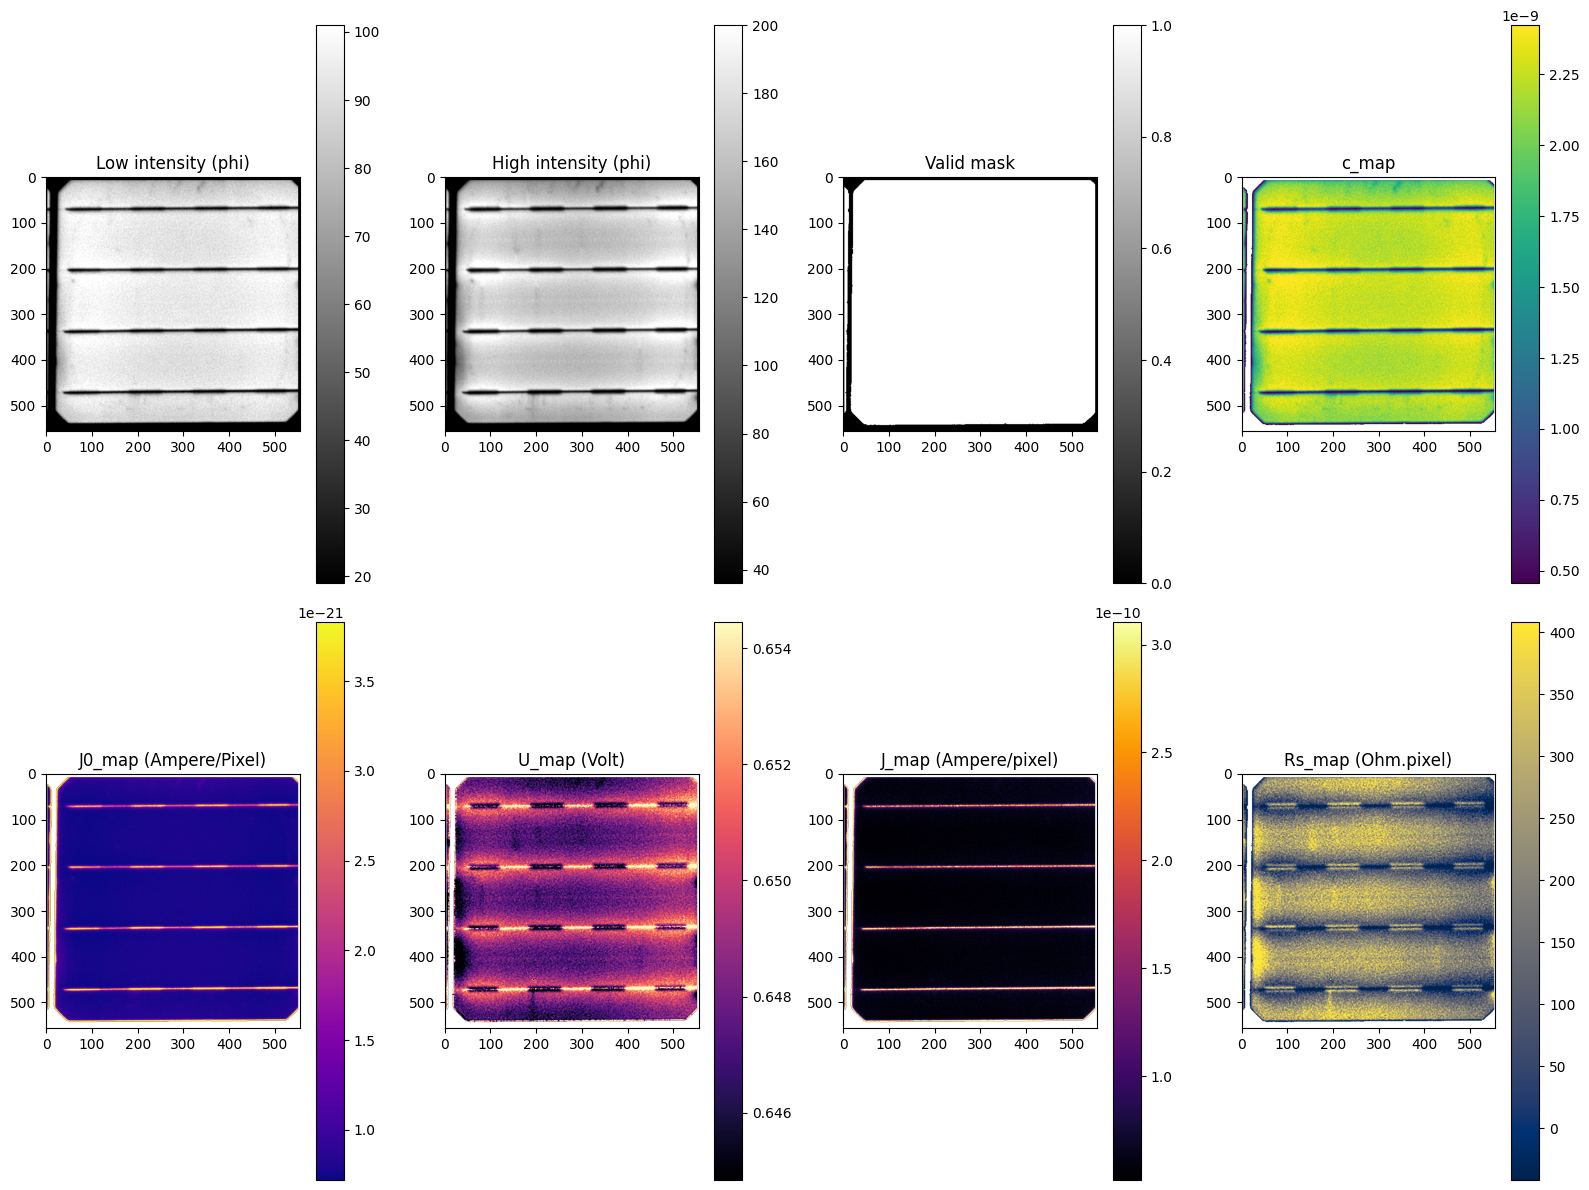

In [12]:
# =========================================================
# CONTOH PAKAI
# =========================================================
low_cell_path  = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_Cell\3922_20_1_01232020_20_wrp\3922_20_1_01232020_20_wrp_001.tiff"
high_cell_path = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_Cell\3922_20_1_01232020_80_wrp\3922_20_1_01232020_80_wrp_001.tiff"

I_low = 0.2 * 9.608
Uth = 0.0259
VT = 38.0
N = 60   # coba mulai dari 1 kalau memang image-nya satu cell

out = run_single_cell_analysis(
    low_cell_path=low_cell_path,
    high_cell_path=high_cell_path,
    I_low=I_low,
    Uth=Uth,
    VT=VT,
    N=N,
    min_valid_intensity= 1e-6
)

SINGLE CELL ANALYSIS
------------------------------------------------------------------------------------------
Low cell file  : 3922_20_1_01232020_20_wrp_001.tiff
High cell file : 3922_20_1_01232020_80_wrp_001.tiff
I_low          : 1.9216000000000002
Uth            : 0.0259
VT             : 38.0
N              : 60
f              : 1.7462386331835855e-30
Vi_low         : 0.6333333333333333
Vi_high        : 0.6520514182878918

INTENSITY SUMMARY
------------------------------------------------------------------------------------------
Low intensity: mean = 87.557797, median = 93.000000, min = 1.000000, max = 173.000000, n = 285982
High intensity: mean = 159.175102, median = 167.000000, min = 1.000000, max = 220.000000, n = 285982

MAP SUMMARY
------------------------------------------------------------------------------------------
c_map       : mean = 0.000000, median = 0.000000, min = 0.000000, max = 0.000000, n = 285982
J0_map      : mean = 0.000000, median = 0.000000, min = 0.000000

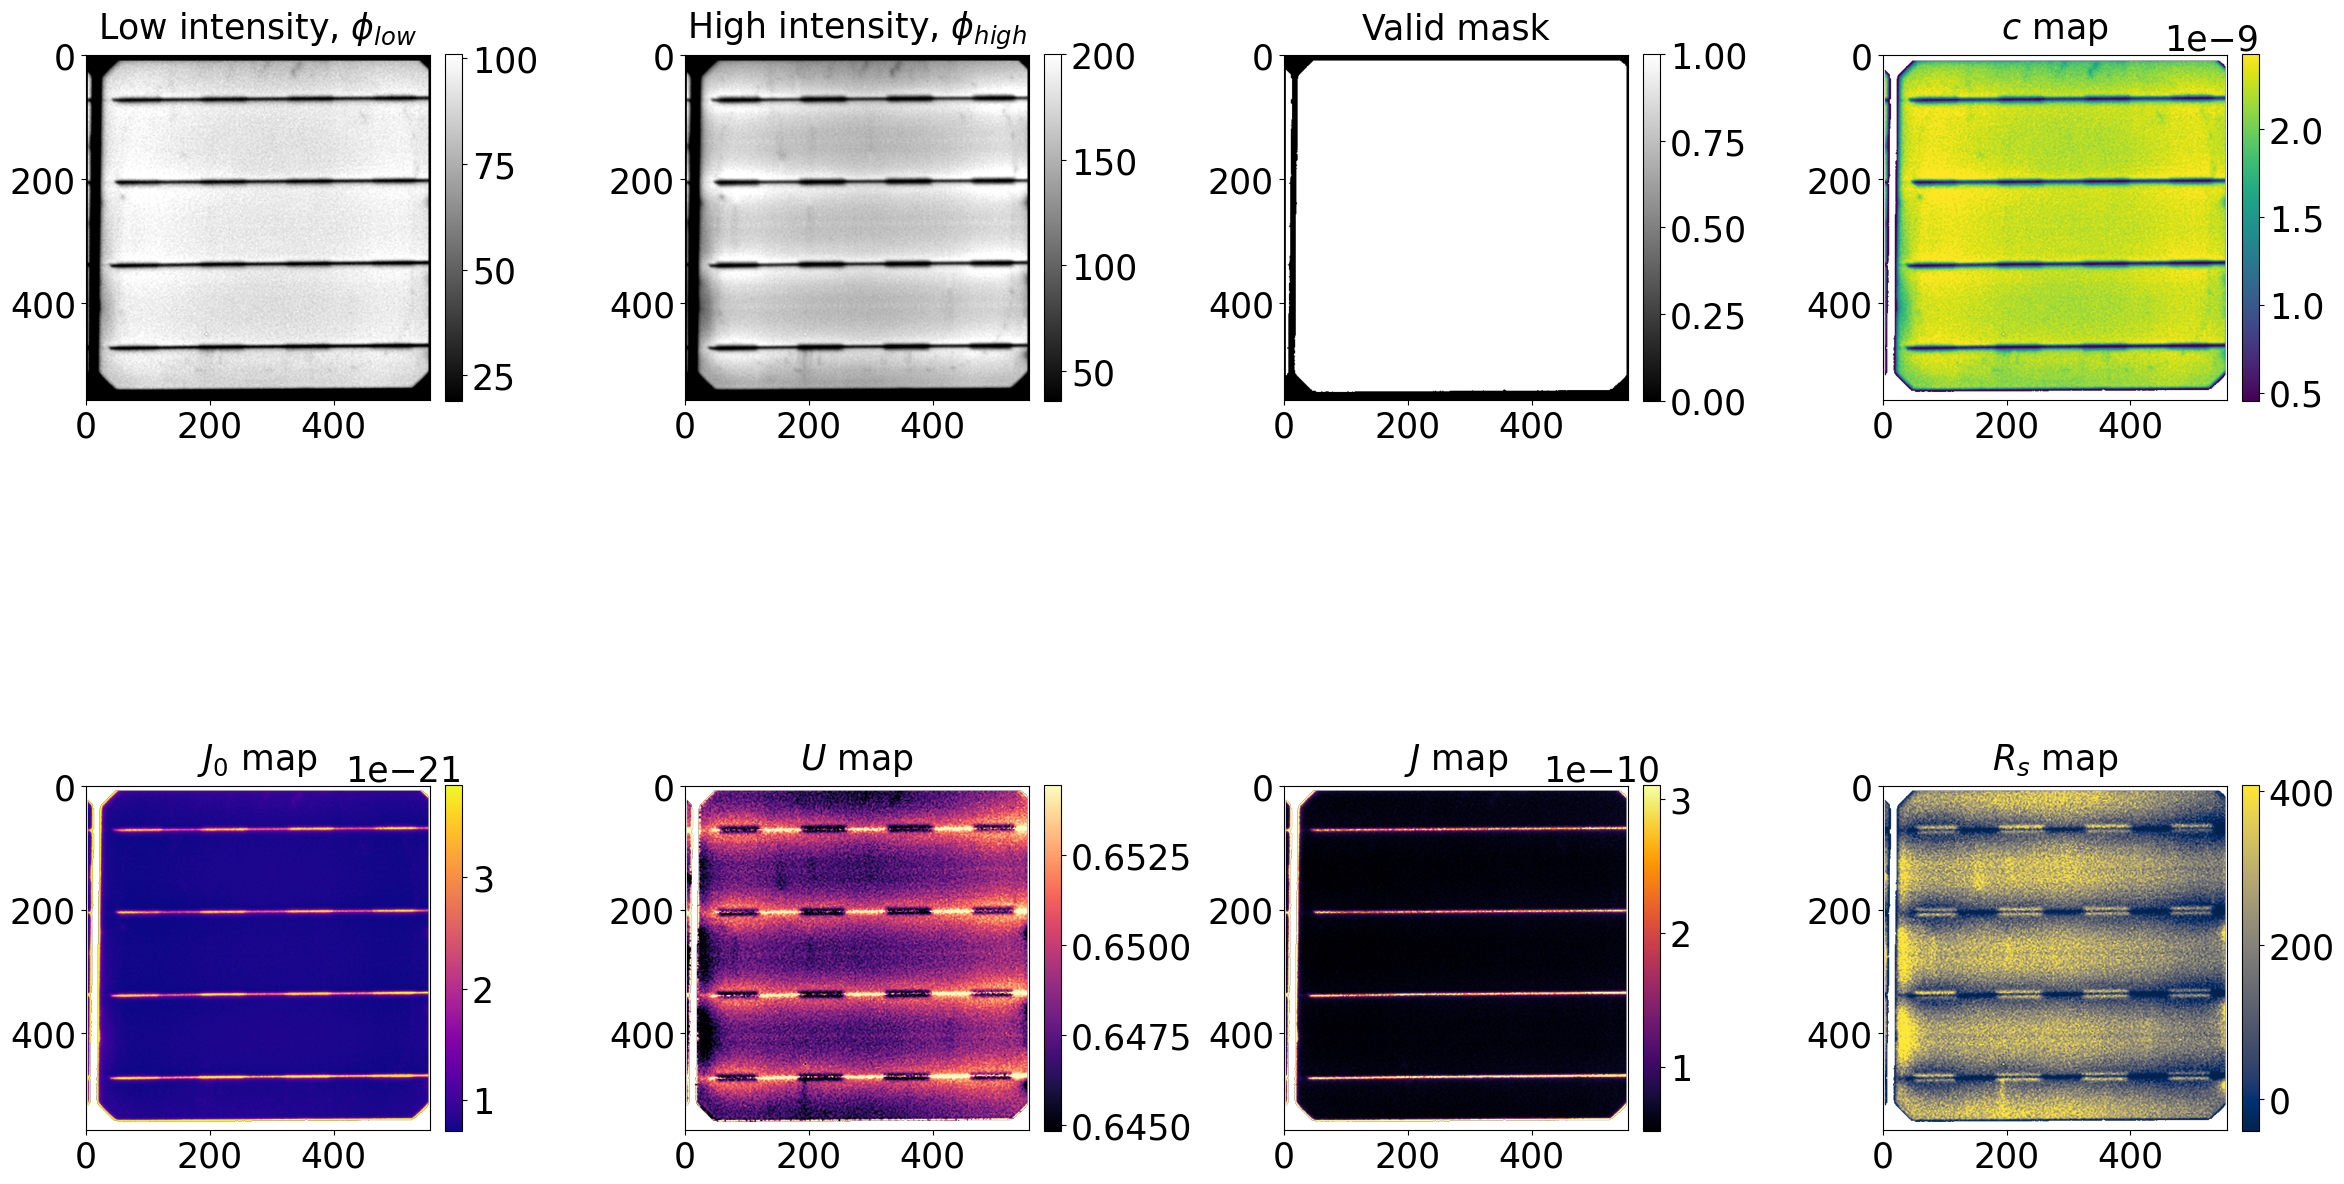

In [13]:
# =========================================================
# CONTOH PAKAI
# =========================================================
low_cell_path  = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_Cell\3922_20_1_01232020_20_wrp\3922_20_1_01232020_20_wrp_001.tiff"
high_cell_path = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_Cell\3922_20_1_01232020_80_wrp\3922_20_1_01232020_80_wrp_001.tiff"

I_low = 0.2 * 9.608
Uth = 0.0259
VT = 38.0
N = 60   # coba mulai dari 1 kalau memang image-nya satu cell

out = run_single_cell_analysis(
    low_cell_path=low_cell_path,
    high_cell_path=high_cell_path,
    I_low=I_low,
    Uth=Uth,
    VT=VT,
    N=N,
    min_valid_intensity= 1e-6
)

In [9]:
import numpy as np

def compute_f(intensity_map, I, Uth=0.0259, VT=0.0, N=1, pixel_area=1.0):
    """
    intensity_map di sini diasumsikan sudah berupa 1D cleaned values
    (padding removed, normalized, clipped).
    """
    phi_valid = np.asarray(intensity_map, dtype=np.float64)

    phi_valid = phi_valid[np.isfinite(phi_valid)]
    phi_valid = phi_valid[phi_valid > 0]

    if phi_valid.size == 0:
        raise ValueError("Tidak ada pixel valid untuk menghitung f.")

    integral_inv_phi = np.sum((1.0 / phi_valid) * pixel_area)

    log_term = np.log(I / integral_inv_phi)
    sum_term = N * (Uth / 2.0) * log_term
    exponent = (sum_term - VT) / (30.0 * Uth)

    return float(np.exp(exponent))

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt


def clip_for_display(img, mask, p_low=2, p_high=98):
    vals = img[mask & np.isfinite(img)]
    if vals.size == 0:
        return img
    lo, hi = np.percentile(vals, [p_low, p_high])
    return np.clip(img, lo, hi)


def summarize_map(name, arr, mask):
    vals = arr[mask & np.isfinite(arr)]
    if vals.size == 0:
        print(f"{name:12s}: tidak ada nilai valid")
        return {
            "mean": np.nan,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n": 0
        }
    elif name in ("J_map", "J0_map"):
        summary = {
            "mean": float(np.mean(vals))*vals.size,
            "median": float(np.median(vals))*vals.size,
            "min": float(np.min(vals))*vals.size,
            "max": float(np.max(vals))*vals.size,
            "n": int(vals.size)
        }
        print(
            f"{name:12s}: "
            f"mean = {summary['mean']:.3e}, "
            f"median = {summary['median']:.3e}, "
            f"min = {summary['min']:.3e}, "
            f"max = {summary['max']:.3e}, "
            f"n = {summary['n']}"
        )
    elif name == "Rs_map":
        summary = {
            "mean": float(np.mean(vals))/vals.size,
            "median": float(np.median(vals))/vals.size,
            "min": float(np.min(vals))/vals.size,
            "max": float(np.max(vals))/vals.size,
            "n": int(vals.size)
        }
        print(
            f"{name:12s}: "
            f"mean = {summary['mean']:.3e}, "
            f"median = {summary['median']:.3e}, "
            f"min = {summary['min']:.3e}, "
            f"max = {summary['max']:.3e}, "
            f"n = {summary['n']}"
        )
    else:
        summary = {
            "mean": float(np.mean(vals)),
            "median": float(np.median(vals)),
            "min": float(np.min(vals)),
            "max": float(np.max(vals)),
            "n": int(vals.size)
        }
        print(
            f"{name:12s}: "
            f"mean = {summary['mean']:.3e}, "
            f"median = {summary['median']:.3e}, "
            f"min = {summary['min']:.3e}, "
            f"max = {summary['max']:.3e}, "
            f"n = {summary['n']}"
        )

    return summary




    


def run_single_cell_analysis(
    low_cell_path,
    high_cell_path,
    I_low,
    Uth=0.0259,
    VT=0.0,
    N=1,
    min_valid_intensity=2
):
    # ----------------------------
    # LOW-BIAS
    # ----------------------------
    phi_low_values = load_image_and_remove_padding(
        low_cell_path,
        min_valid_intensity=min_valid_intensity
    )
    phi_low_values = trim_outliers(
        phi_low_values,
        lower_percentile=0.1,
        upper_percentile=99.9
    )

    f = compute_f(phi_low_values, I=I_low, Uth=Uth, VT=VT, N=N)
    Vi_low = compute_Vi_from_phi_values(phi_low_values, I=I_low, f=f, Uth=Uth)

    phi_low_img = load_gray_cv2(low_cell_path)
    c_map, mask_low = compute_c_map(
        phi_low_img,
        Vi=Vi_low,
        Uth=Uth,
        min_valid_intensity=min_valid_intensity
    )
    J0_map = compute_J0_map(c_map, f=f)

    # ----------------------------
    # HIGH-BIAS
    # ----------------------------
    phi_high_img = load_gray_cv2(high_cell_path)
    mask_high = make_valid_mask(phi_high_img, min_valid_intensity=min_valid_intensity)
    mask = mask_low & mask_high

    U_map = compute_U_map(
        phi_high_img,
        c_map=c_map,
        Uth=Uth,
        mask=mask
    )

    Vi_high = estimate_Vi_from_brightest(
        phi_high_img,
        U_map=U_map,
        mask=mask,
        exclude_top_percent=0.1,
        band_width_percent=0.4
    )

    J_map = compute_J_map(
        J0_map=J0_map,
        U_map=U_map,
        Uth=Uth,
        mask=mask
    )

    Rs_map = compute_Rs_map(
        Vi=Vi_high,
        U_map=U_map,
        J_map=J_map,
        mask=mask
    )

    # ----------------------------
    # SUMMARY
    # ----------------------------
    print("=" * 90)
    print("SINGLE CELL ANALYSIS")
    print("-" * 90)
    print("Low cell file  :", os.path.basename(low_cell_path))
    print("High cell file :", os.path.basename(high_cell_path))
    print(f"I_low          : {I_low}")
    print(f"Uth            : {Uth}")
    print(f"VT             : {VT}")
    print(f"N              : {N}")
    print(f"f              : {f}")
    print(f"Vi_low         : {Vi_low}")
    print(f"Vi_high        : {Vi_high}")
    print("=" * 90)

    summaries = {}

    # intensity summaries
    low_vals_valid = phi_low_img[mask & np.isfinite(phi_low_img)]
    high_vals_valid = phi_high_img[mask & np.isfinite(phi_high_img)]

    print("\nINTENSITY SUMMARY")
    print("-" * 90)

    if low_vals_valid.size > 0:
        print(
            f"{'Low intensity':12s}: "
            f"mean = {np.mean(low_vals_valid):.3e}, "
            f"median = {np.median(low_vals_valid):.3e}, "
            f"min = {np.min(low_vals_valid):.3e}, "
            f"max = {np.max(low_vals_valid):.3e}, "
            f"n = {low_vals_valid.size}"
        )
        summaries["low_intensity_mean"] = float(np.mean(low_vals_valid))
    else:
        print("Low intensity: tidak ada nilai valid")
        summaries["low_intensity_mean"] = np.nan

    if high_vals_valid.size > 0:
        print(
            f"{'High intensity':12s}: "
            f"mean = {np.mean(high_vals_valid):.3e}, "
            f"median = {np.median(high_vals_valid):.3e}, "
            f"min = {np.min(high_vals_valid):.3e}, "
            f"max = {np.max(high_vals_valid):.3e}, "
            f"n = {high_vals_valid.size}"
        )
        summaries["high_intensity_mean"] = float(np.mean(high_vals_valid))
    else:
        print("High intensity: tidak ada nilai valid")
        summaries["high_intensity_mean"] = np.nan

    print("\nMAP SUMMARY")
    print("-" * 90)
    summaries["c_map"] = summarize_map("c_map", c_map, mask)
    summaries["J0_map"] = summarize_map("J0_map", J0_map, mask)
    summaries["U_map"] = summarize_map("U_map", U_map, mask)
    summaries["J_map"] = summarize_map("J_map", J_map, mask)
    summaries["Rs_map"] = summarize_map("Rs_map", Rs_map, mask)

    # ----------------------------
    # DISPLAY IMAGES
    # ----------------------------
    phi_low_disp = clip_for_display(phi_low_img, mask, 2, 98)
    phi_high_disp = clip_for_display(phi_high_img, mask, 2, 98)
    c_disp = clip_for_display(c_map, mask, 2, 98)
    J0_disp = clip_for_display(J0_map, mask, 2, 98)
    U_disp = clip_for_display(U_map, mask, 2, 98)
    J_disp = clip_for_display(J_map, mask, 2, 98)
    Rs_disp = clip_for_display(Rs_map, mask, 2, 98)

    mask_disp = np.where(mask, 1.0, 0.0)

    plt.figure(figsize=(16, 12))

    plt.subplot(2, 4, 1)
    plt.imshow(phi_low_disp, cmap="gray")
    plt.title("Low intensity (phi)")
    plt.colorbar()

    plt.subplot(2, 4, 2)
    plt.imshow(phi_high_disp, cmap="gray")
    plt.title("High intensity (phi)")
    plt.colorbar()

    plt.subplot(2, 4, 3)
    plt.imshow(mask_disp, cmap="gray")
    plt.title("Valid mask")
    plt.colorbar()

    plt.subplot(2, 4, 4)
    plt.imshow(c_disp, cmap="viridis")
    plt.title("c_map")
    plt.colorbar()

    plt.subplot(2, 4, 5)
    plt.imshow(J0_disp, cmap="plasma")
    plt.title("J0_map (Ampere/Pixel)")
    plt.colorbar()

    plt.subplot(2, 4, 6)
    plt.imshow(U_disp, cmap="magma")
    plt.title("U_map (Volt)")
    plt.colorbar()

    plt.subplot(2, 4, 7)
    plt.imshow(J_disp, cmap="inferno")
    plt.title("J_map (Ampere/pixel)")
    plt.colorbar()

    plt.subplot(2, 4, 8)
    plt.imshow(Rs_disp, cmap="cividis")
    plt.title("Rs_map (Ohm.pixel)")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    return {
        "f": f,
        "Vi_low": Vi_low,
        "Vi_high": Vi_high,
        "mask": mask,
        "phi_low_img": phi_low_img,
        "phi_high_img": phi_high_img,
        "c_map": c_map,
        "J0_map": J0_map,
        "U_map": U_map,
        "J_map": J_map,
        "Rs_map": Rs_map,
        "summaries": summaries
    }




## Rp Estimation Program Chech

### Fungsi-fungsi

In [9]:

def estimate_rparallel_per_cell(
    folder_low_cells: str,
    Jc: float,
    J0: float,
    nid: float = 1.2,
    Vth: float = 0.0259,
    rref_p: float = 1e6,
    min_valid_intensity: int = 2,
    pattern: str = "*_cell_*.tif*"
):
    """
    Menghasilkan Rp tiap cell dalam satu folder.
    """
    paths = sorted(glob.glob(os.path.join(folder_low_cells, pattern)))
    if not paths:
        raise FileNotFoundError(f"Tidak ada file cocok pattern {pattern} di {folder_low_cells}")

    cell_names = []
    phi_means = []

    for p in paths:
        img = load_gray_tiff_cv2(p)
        phi = mean_intensity_excluding_padding(img, min_valid=min_valid_intensity)
        cell_names.append(os.path.basename(p))
        phi_means.append(phi)

    phi_means = np.array(phi_means, dtype=np.float64)

    idx_ref = int(np.nanargmax(phi_means))
    phi_ref = float(phi_means[idx_ref])
    ref_cell = cell_names[idx_ref]

    CPRA = compute_CPRA(phi_ref=phi_ref, J0=J0, nid=nid, Vth=Vth, rref_p=rref_p)

    rps = []
    for phi in phi_means:
        rp = rp_from_mean_intensity(
            phi_i=float(phi),
            CPRA=CPRA,
            Jc=Jc,
            J0=J0,
            nid=nid,
            Vth=Vth
        )
        rps.append(rp)

    rps = np.array(rps, dtype=np.float64)

    return {
        "cell_names": cell_names,
        "phi_mean": phi_means,
        "rp_ohm_cm2": rps,
        "ref_cell": ref_cell,
        "phi_ref": phi_ref,
        "CPRA": CPRA
    }


def print_rp_summary_for_folder(
    folder_low_cells: str,
    Jc: float,
    J0: float,
    nid: float = 1.2,
    Vth: float = 0.0259,
    rref_p: float = 1e6,
    min_valid_intensity: int = 2,
    pattern: str = "*_wrp_*.tiff*"
):
    """
    Jalankan perhitungan Rp untuk satu folder lalu print hasil tiap cell
    dan summary folder.
    """
    out = estimate_rparallel_per_cell(
        folder_low_cells=folder_low_cells,
        Jc=Jc,
        J0=J0,
        nid=nid,
        Vth=Vth,
        rref_p=rref_p,
        min_valid_intensity=min_valid_intensity,
        pattern=pattern
    )

    print("=" * 80)
    print("FOLDER :", folder_low_cells)
    print("Reference cell :", out["ref_cell"])
    print("Phi ref        :", out["phi_ref"])
    print("CPRA           :", out["CPRA"])
    print("=" * 80)
    print()

    print("HASIL Rp PER CELL")
    print("-" * 80)
    for name, phi, rp in zip(out["cell_names"], out["phi_mean"], out["rp_ohm_cm2"]):
        print(f"{name:40s} | phi_mean = {phi:10.4f} | Rp = {rp:15.6f} ohm.cm^2")

    valid_rp = out["rp_ohm_cm2"][np.isfinite(out["rp_ohm_cm2"])]

    print()
    print("=" * 80)
    print("RINGKASAN FOLDER")
    print("-" * 80)
    print("Jumlah cell total  :", len(out["cell_names"]))
    print("Jumlah Rp valid    :", len(valid_rp))

    if len(valid_rp) > 0:
        print("Rp rata-rata       :", float(np.mean(valid_rp)), "ohm.cm^2")
        print("Rp median          :", float(np.median(valid_rp)), "ohm.cm^2")
        print("Rp minimum         :", float(np.min(valid_rp)), "ohm.cm^2")
        print("Rp maksimum        :", float(np.max(valid_rp)), "ohm.cm^2")
    else:
        print("Tidak ada Rp valid.")
    print("=" * 80)

    return out



### RUN !!

In [10]:
# -------------------------------------------------------------------
# CONTOH PAKAI
# -------------------------------------------------------------------
if __name__ == "__main__":
    folder_low = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_Cell\3922_20_1_01232020_20_wrp"

    # Contoh parameter
    Jc = 0.0025
    J0 = 1e-9
    nid = 1.2
    Vth = 0.0259
    rref_p = 1e6

    print_rp_summary_for_folder(
        folder_low_cells=folder_low,
        Jc=Jc,
        J0=J0,
        nid=nid,
        Vth=Vth,
        rref_p=rref_p
    )

FOLDER : C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\EL_Cell\3922_20_1_01232020_20_wrp
Reference cell : 3922_20_1_01232020_20_wrp_056.tiff
Phi ref        : 124.22268676757812
CPRA           : 124.22268676757812

HASIL Rp PER CELL
--------------------------------------------------------------------------------
3922_20_1_01232020_20_wrp_000.tiff       | phi_mean =    88.6308 | Rp =             nan ohm.cm^2
3922_20_1_01232020_20_wrp_001.tiff       | phi_mean =    87.7471 | Rp =             nan ohm.cm^2
3922_20_1_01232020_20_wrp_002.tiff       | phi_mean =    73.8633 | Rp =             nan ohm.cm^2
3922_20_1_01232020_20_wrp_003.tiff       | phi_mean =    71.2959 | Rp =             nan ohm.cm^2
3922_20_1_01232020_20_wrp_004.tiff       | phi_mean =    80.2942 | Rp =             nan ohm.cm^2
3922_20_1_01232020_20_wrp_005.tiff       | phi_mean =    76.9498 | Rp =             nan ohm.cm^2
3922_20_1_01232020_20_wrp_006.tiff       | phi_mean =    75.9900 

## Real Uniting Program